# Task 5 — A real time series

**Data Visualization — Week 1 assignment, Task 5** · dataset: `data/flights.csv`

Monthly airline passenger totals (thousands of passengers) from January 1949 to December 1960 — the classic
Box & Jenkins airline series. 144 rows, nothing missing, so all the difficulty is in the design.

| Step | Question | Chart |
|---|---|---|
| 1 | How did traffic change over the 12 years? | One line on a real time axis |
| 2 | What does the within-year cycle look like on its own? | One line per year, months on the x-axis |
| 3 | Which month is consistently busiest? | Bar chart of each month's share of the year |
| 4 | Which chart belongs in a report? | — written |
| Q | Is the seasonal swing growing, or is the airline just growing? | One extra chart that settles it |

## 0. Setup

Same house style as the lecture notebook: the eight-hue colour-blind-safe palette, recessive grid, no chart
border, titles on the left. Every chart below inherits it, and every chart is also saved to `charts/`.

I added one small helper, `footnote()`, because several charts in this task have to **declare excluded
rows on the chart itself**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (same as the lecture) ---------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]

INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

# ---- House style ---------------------------------------------------
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    # Every chart is also exported to charts/ so it can go straight into a report.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)


def footnote(ax, text, y=-0.18):
    # Small grey note under the chart - used to declare exclusions ON the chart.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)


print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.2


---

# Meet the data

In [2]:
flights = pd.read_csv(DATA / "flights.csv")
print("Rows:", flights.shape[0], " Columns:", flights.shape[1])
print("Missing values:", int(flights.isna().sum().sum()))
print("Years:", flights["year"].min(), "-", flights["year"].max())
print("Months per year:", flights.groupby("year").size().unique())
flights.head()

Rows: 144  Columns: 3
Missing values: 0
Years: 1949 - 1960
Months per year: [12]


,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121


---

# Step 1 — One ordered time axis

**This is the real work of the task.** `year` and `month` are two separate columns, and `month` is stored as
*text*. Text sorts alphabetically — April, August, December, February… — so if I plotted months as they are,
the line would jump around in the wrong order. I need to turn each `(year, month)` pair into one real date.

Parsing to a proper `datetime` is better than inventing an index like `year * 12 + month`: matplotlib then
spaces and labels the axis as a calendar, and every later step (grouping by month, sorting) works correctly.

In [3]:
MONTHS = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]

df = flights.copy()
# "1949" + "January" -> 1949-01-01. %B is the full month name.
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str), format="%Y-%B")
# An ordered categorical so months sort in calendar order, not alphabetically.
df["month"] = pd.Categorical(df["month"], categories=MONTHS, ordered=True)
df = df.sort_values("date").reset_index(drop=True)

# Sanity checks: 144 distinct, strictly increasing, evenly monthly dates.
assert df["date"].is_unique and df["date"].is_monotonic_increasing
assert (df["date"].diff().dropna().dt.days.between(28, 31)).all()
print("First:", df["date"].min().date(), " Last:", df["date"].max().date(), " Points:", len(df))
df[["date", "year", "month", "passengers"]].head(14)

First: 1949-01-01  Last: 1960-12-01  Points: 144


,date,year,month,passengers
0,1949-01-01,1949,January,112
1,1949-02-01,1949,February,118
2,1949-03-01,1949,March,132
3,1949-04-01,1949,April,129
4,1949-05-01,1949,May,121
5,1949-06-01,1949,June,135
6,1949-07-01,1949,July,148
7,1949-08-01,1949,August,148
8,1949-09-01,1949,September,136
9,1949-10-01,1949,October,119


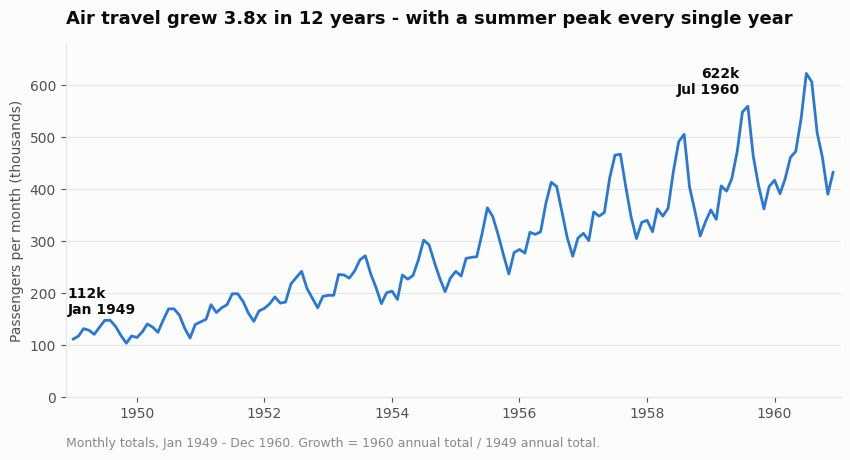

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.6))

ax.plot(df["date"], df["passengers"], color=BLUE, linewidth=2, zorder=3)

# Label only the start and the end.
first, last = df.iloc[0], df.iloc[-1]
ax.annotate(f"{first['passengers']}k\nJan 1949", (first["date"], first["passengers"]),
            textcoords="offset points", xytext=(-4, 18), ha="left",
            fontsize=10, fontweight="bold", color=INK)
peak = df.loc[df["passengers"].idxmax()]
ax.annotate(f"{peak['passengers']}k\n{peak['date']:%b %Y}", (peak["date"], peak["passengers"]),
            textcoords="offset points", xytext=(-48, -6), ha="right", va="center",
            fontsize=10, fontweight="bold", color=INK)

annual = df.groupby("year")["passengers"].sum()
growth = annual[1960] / annual[1949]
ax.set_title(f"Air travel grew {growth:.1f}x in 12 years - with a summer peak every single year")
ax.set_ylabel("Passengers per month (thousands)")
ax.set_ylim(0, 680)
ax.margins(x=0.01)
ax.xaxis.grid(False)
footnote(ax, "Monthly totals, Jan 1949 - Dec 1960. Growth = 1960 annual total / 1949 annual total.", y=-0.14)

save(fig, "task5_01_passengers_over_time")
plt.show()

**Why a line chart:** time is ordered and evenly spaced, and the question is how traffic *changes*; a single
line reads as one continuous series. The y-axis starts at zero so the growth looks like what it is — nearly a
4× increase.

The chart shows **two patterns tangled together**: a long-term rise (the trend) and a saw-tooth that repeats
every year (the seasonal cycle). The next chart pulls them apart.

---

# Step 2 — Isolate the seasonal cycle

Put **months on the x-axis** and draw **one line per year**. Now each line is one year's seasonal profile, and
the trend shows up only as the lines stacking higher, instead of tilting the whole chart.

**Colour.** Twelve lines would normally be too many to colour individually. But here the years have a
natural *order*, so I use a **sequential** scale — light for 1949, dark for 1960 — instead of twelve unrelated
hues. The reader does not need to identify each year; they only need "lighter = earlier". I label just the
first and last year directly. No legend.

In [5]:
pivot = df.pivot(index="year", columns="month", values="passengers")  # 12 years x 12 months
pivot = pivot[MONTHS]
pivot

month,January,February,March,April,May,June,July,August,September,October,November,December
year,,,,,,,,,,,,
1949,112,118,132,129,121,135,148,148,136,119,104,118
1950,115,126,141,135,125,149,170,170,158,133,114,140
1951,145,150,178,163,172,178,199,199,184,162,146,166
1952,171,180,193,181,183,218,230,242,209,191,172,194
1953,196,196,236,235,229,243,264,272,237,211,180,201
1954,204,188,235,227,234,264,302,293,259,229,203,229
1955,242,233,267,269,270,315,364,347,312,274,237,278
1956,284,277,317,313,318,374,413,405,355,306,271,306
1957,315,301,356,348,355,422,465,467,404,347,305,336


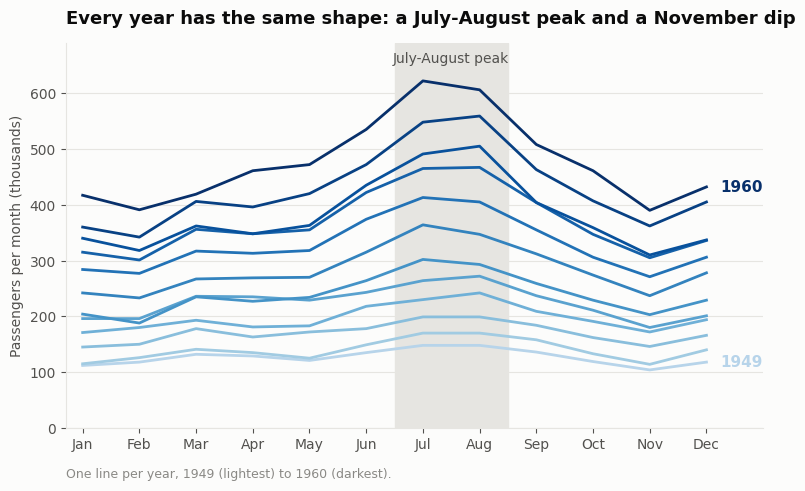

In [6]:
years = pivot.index.tolist()
cmap = plt.get_cmap("Blues")
shades = [cmap(v) for v in np.linspace(0.3, 1.0, len(years))]
month_abbr = [m[:3] for m in MONTHS]

fig, ax = plt.subplots(figsize=(9, 5))
for year, colour in zip(years, shades):
    ax.plot(month_abbr, pivot.loc[year], color=colour, linewidth=2, zorder=3)

for year in (years[0], years[-1]):
    ax.text(11.25, pivot.loc[year, "December"], str(year), color=shades[years.index(year)],
            fontsize=11, fontweight="bold", va="center")

# Shade the peak months - this is where the message is.
ax.axvspan(5.5, 7.5, color=GRID, zorder=1)
ax.text(6.5, 655, "July-August peak", ha="center", fontsize=10, color=INK_SOFT)

ax.set_title("Every year has the same shape: a July-August peak and a November dip")
ax.set_ylabel("Passengers per month (thousands)")
ax.set_ylim(0, 690)
ax.set_xlim(-0.3, 12.0)
ax.xaxis.grid(False)
footnote(ax, "One line per year, 1949 (lightest) to 1960 (darkest).", y=-0.13)

save(fig, "task5_02_seasonal_cycle_by_year")
plt.show()

**Why this chart:** months are an ordered cycle, so a line per year shows each year's *shape*, and stacking the
years on top of each other makes it obvious that the shape repeats while the level rises. Every year rises
from a winter low to a July–August peak, falls sharply in September–November, then ticks up for December.

---

# Step 3 — Which month is consistently busiest?

"Consistently" means *in every year*, so raw passenger counts are the wrong measure: a 1960 August is bigger
than a 1949 August just because the airline grew. Instead, for each year I compute **each month's share of
that year's total**, then average across the 12 years. A month with 1/12 of the traffic scores 8.3%.

I also check, year by year, which month was the actual peak — counting ties as a tie, not giving them to
whichever month comes first.

In [7]:
share = pivot.div(pivot.sum(axis=1), axis=0) * 100   # each month as % of its year
avg_share = share.mean().round(2)

peak_months = pivot.apply(lambda row: " & ".join(m for m in MONTHS if row[m] == row.max()), axis=1)
print("Busiest month in each year:")
print(peak_months.to_string())
print()
print("Years where the peak was July or August:",
      int(peak_months.str.contains("July|August").sum()), "of", len(peak_months))
avg_share.to_frame("average % of the year's passengers")

Busiest month in each year:
year
1949    July & August
1950    July & August
1951    July & August
1952           August
1953           August
1954             July
1955             July
1956             July
1957           August
1958           August
1959           August
1960             July

Years where the peak was July or August: 12 of 12


,average % of the year's passengers
month,
January,7.18
February,7.10
March,8.17
April,7.99
May,8.05
June,9.19
July,10.30
August,10.31
September,9.01


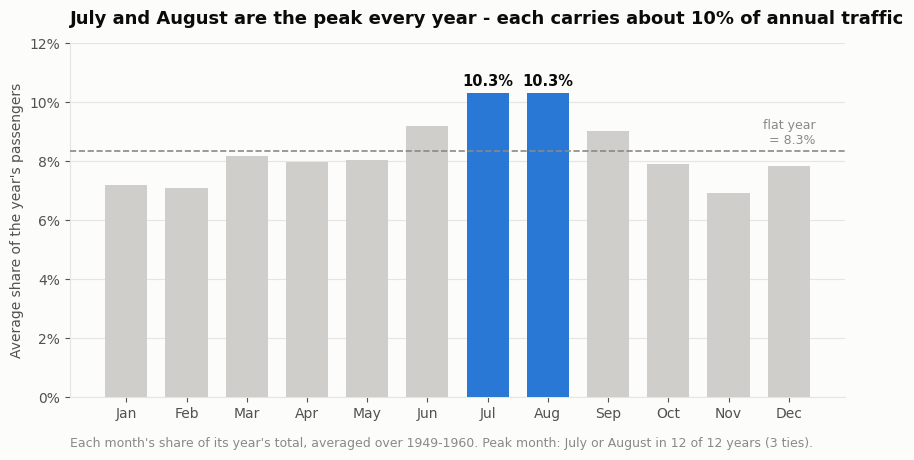

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.6))

peak = {"July", "August"}
colours = [BLUE if m in peak else QUIET for m in MONTHS]
bars = ax.bar(month_abbr, avg_share.values, color=colours, width=0.7, zorder=3)

for bar, m, v in zip(bars, MONTHS, avg_share.values):
    if m in peak:
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.15, f"{v:.1f}%", ha="center",
                va="bottom", fontsize=10.5, fontweight="bold", color=INK)

# Reference: a perfectly flat year.
ax.axhline(100 / 12, color=INK_MUTED, linewidth=1.2, linestyle="--", zorder=4)
ax.text(11.45, 100 / 12 + 0.15, "flat year\n= 8.3%", ha="right", va="bottom", fontsize=9, color=INK_MUTED)

ax.set_title("July and August are the peak every year - each carries about 10% of annual traffic")
ax.set_ylabel("Average share of the year's passengers")
ax.set_ylim(0, 12)
ax.yaxis.set_major_formatter(lambda v, p: f"{v:.0f}%")
ax.xaxis.grid(False)
ax.set_axisbelow(True)
footnote(ax, "Each month's share of its year's total, averaged over 1949-1960. "
             "Peak month: July or August in 12 of 12 years (3 ties).", y=-0.14)

save(fig, "task5_03_busiest_month_share")
plt.show()

**Why a bar chart:** the question compares twelve categories on one number, so it is a bar chart — kept in
**calendar order** rather than sorted by value, because months have a natural order and the reader expects
January to December. Grey for the ten context months, blue for the two that answer the question, a zero
baseline, and only the two bars that matter carry labels.

**Answer:** it is not one month but a pair. **July and August are essentially tied** (10.30% vs 10.31% on
average). One of them is the busiest month in all 12 years: August alone in 5 years, July alone in 4, and
exactly tied in 3. November is the quietest month (6.9%).

---

# Step 4 — Which chart goes in the report?

It depends on the report's one question, but if I can include only one I would choose **Chart 1** (the single
line over time). For a report about the airline, the headline is growth — traffic nearly quadrupled — and
Chart 1 is the only one that shows that while still showing the seasonal cycle as the saw-tooth. It is also
the chart any reader can read without explanation.

Why the other two do not belong *in the same report*:

- **Chart 2 repeats Chart 1.** It is the same 144 numbers rearranged. Putting both in one report makes the
  reader decode the same data twice in two different layouts, and its twelve lines need more explanation
  than they add for a reader who has already seen Chart 1.
- **Chart 3 answers a different, narrower question** ("when do we need the most capacity?"). It belongs in a
  report about scheduling or staffing, not one about growth — there it would be the headline chart. It also
  throws away the growth on purpose (shares, not counts), so next to Chart 1 it would seem to contradict it.

One chart, one message: a report should have one chart per message, not three views of one dataset.

---

# The written question — is the seasonality growing, or is the airline just growing?

In Chart 1 the summer peaks get visibly taller every year. There are two possible explanations:

1. **The airline is growing, and seasonality is proportional.** If summer is always, say, 20% above average,
   then 20% of a bigger number is a bigger swing. The swing grows in passengers but not in *percent*. (This
   is called **multiplicative** seasonality.)
2. **Seasonality itself is getting stronger** — summer is becoming a bigger share of the year.

Chart 1 cannot tell these apart, because it shows raw counts. **The chart that settles it removes the growth:**
divide each month by its own year's average month. Then 100 means an average month and 125 means 25% above
average — in every year, regardless of how big the airline was. If the lines for all years land on top of each
other, explanation 1 is right. If later years have taller peaks, explanation 2 is also happening.

(An equivalent alternative is Chart 1 with a **log-scale** y-axis: on a log axis a constant percentage swing
draws as a constant height, so a growing saw-tooth would mean growing seasonality.)

In [9]:
seasonal_index = pivot.div(pivot.mean(axis=1), axis=0) * 100   # 100 = that year's average month

print("Peak month, % of the year's average month:")
print(seasonal_index.max(axis=1).round(0).astype(int).to_string())
print()
print("Trough month, % of the year's average month:")
print(seasonal_index.min(axis=1).round(0).astype(int).to_string())

Peak month, % of the year's average month:
year
1949    117
1950    122
1951    117
1952    123
1953    121
1954    126
1955    128
1956    126
1957    127
1958    133
1959    131
1960    131

Trough month, % of the year's average month:
year
1949    82
1950    82
1951    85
1952    87
1953    80
1954    79
1955    82
1956    83
1957    82
1958    81
1959    80
1960    82


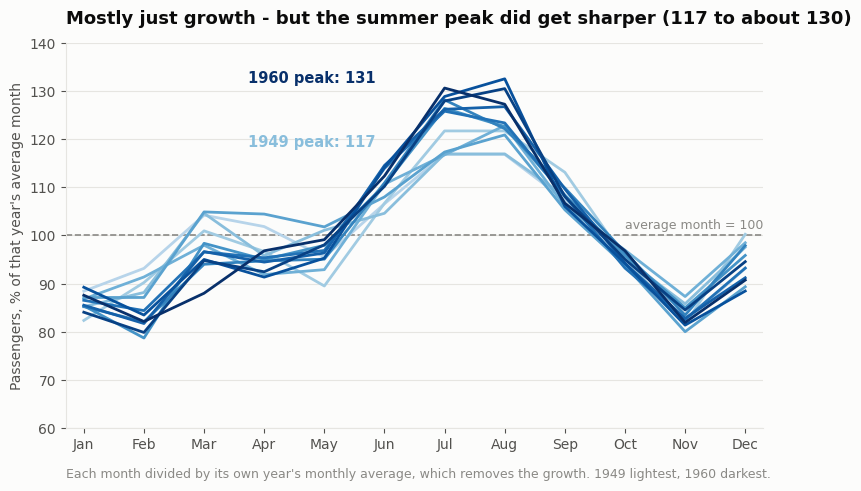

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

for year, colour in zip(years, shades):
    ax.plot(month_abbr, seasonal_index.loc[year], color=colour, linewidth=2, zorder=3)

ax.axhline(100, color=INK_MUTED, linewidth=1.2, linestyle="--", zorder=2)
ax.text(9.0, 101.5, "average month = 100", fontsize=9, color=INK_MUTED)

for year in (years[0], years[-1]):
    peak_val = seasonal_index.loc[year].max()
    ax.text(4.85, peak_val + (2 if year == years[-1] else 2.5), f"{year} peak: {peak_val:.0f}",
            color=shades[years.index(year)] if year == years[-1] else shades[2],
            fontsize=10.5, fontweight="bold", va="center", ha="right")

ax.set_title("Mostly just growth - but the summer peak did get sharper (117 to about 130)")
ax.set_ylabel("Passengers, % of that year's average month")
ax.set_ylim(60, 140)
ax.set_xlim(-0.3, 11.3)
ax.xaxis.grid(False)
footnote(ax, "Each month divided by its own year's monthly average, which removes the growth. "
             "1949 lightest, 1960 darkest.", y=-0.13)

save(fig, "task5_04_seasonality_without_growth")
plt.show()

### Answer

**Mostly the airline is growing — but not only that.** Once growth is removed, the twelve years collapse onto
nearly the same shape. The winter months stay at about 80–90% of an average month in every year, from 1949 to
1960. So most of the widening swing in Chart 1 is just a constant *percentage* swing applied to a much bigger
airline.

The summer peak, though, does drift upward: about 117% of an average month in 1949–1953, and about 127–133%
by 1957–1960, with the darker lines sitting clearly above the lighter ones in July and August. So summer
became a somewhat larger share of the year as well — seasonality grew modestly *on top of* the growth effect.

**Practical consequence:** this is why analysts usually model this series on a log scale. Taking logs turns
the proportional swing into a constant one, so trend and seasonality can be separated cleanly.